In [452]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch

torch.manual_seed(42)
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
lr = 0.001
batch_size = 128
epochs = 1000
train_test_ratio = 0.8

device

device(type='mps')

In [453]:
from torch.utils.data import Dataset, DataLoader, random_split

class ClastersDataset(Dataset):
    from sklearn import datasets 
    def __init__(self):
        classes = datasets.make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=1)
        self.X = torch.tensor(classes[0], dtype=torch.float32)
        self.y = torch.tensor(classes[1], dtype=torch.int32)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

my_dataset = ClastersDataset()
train, test = random_split(my_dataset, [train_test_ratio, 1 - train_test_ratio])

train_dataloader = DataLoader(train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test, batch_size=batch_size, shuffle=True)

In [454]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(2, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
        )
        
    def forward(self, x):
        return self.linear(x)
    
net = Net().to(device)

In [455]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(net.parameters(), lr=lr)

In [456]:
def train_model(model, train_dataloader, criterion, optimizer):
    model.train()
    sum_loss = 0
    size = len(train_dataloader.dataset)
    for batch, (X, y) in enumerate(train_dataloader, 0):
        X, y = X.to(device), y.to(device)
        y = y.float().unsqueeze(1)
        pred = model(X)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        sum_loss += loss.item()

    return sum_loss / size

def test_model(model, test_dataloader, criterion):
    model.eval()
    sum_loss = 0
    size = len(test_dataloader.dataset)
    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            y = y.float().unsqueeze(1)
            pred = model(X)
            loss = criterion(pred, y)
            sum_loss += loss.item()

    return sum_loss / size

In [457]:
for epoch in range(epochs):
    train_loss = train_model(net, train_dataloader, criterion, optimizer)
    test_loss = test_model(net, test_dataloader, criterion)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

Epoch 1/1000, Train Loss: 0.0080, Test Loss: 0.0330
Epoch 2/1000, Train Loss: 0.0080, Test Loss: 0.0329
Epoch 3/1000, Train Loss: 0.0080, Test Loss: 0.0328
Epoch 4/1000, Train Loss: 0.0080, Test Loss: 0.0328
Epoch 5/1000, Train Loss: 0.0080, Test Loss: 0.0327
Epoch 6/1000, Train Loss: 0.0080, Test Loss: 0.0326
Epoch 7/1000, Train Loss: 0.0079, Test Loss: 0.0325
Epoch 8/1000, Train Loss: 0.0079, Test Loss: 0.0325
Epoch 9/1000, Train Loss: 0.0079, Test Loss: 0.0324
Epoch 10/1000, Train Loss: 0.0079, Test Loss: 0.0323
Epoch 11/1000, Train Loss: 0.0079, Test Loss: 0.0323
Epoch 12/1000, Train Loss: 0.0079, Test Loss: 0.0322
Epoch 13/1000, Train Loss: 0.0078, Test Loss: 0.0321
Epoch 14/1000, Train Loss: 0.0078, Test Loss: 0.0320
Epoch 15/1000, Train Loss: 0.0078, Test Loss: 0.0320
Epoch 16/1000, Train Loss: 0.0078, Test Loss: 0.0319
Epoch 17/1000, Train Loss: 0.0078, Test Loss: 0.0318
Epoch 18/1000, Train Loss: 0.0078, Test Loss: 0.0318
Epoch 19/1000, Train Loss: 0.0078, Test Loss: 0.0317
Ep

y:	[1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1]
pred:	[1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1]


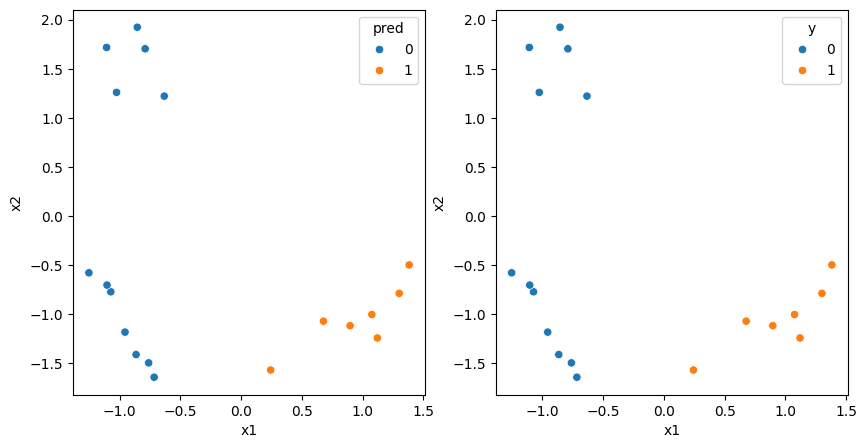

In [458]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

X, y = next(iter(test_dataloader))
X, y = X.to(device), y.to(device)

net.eval()
with torch.inference_mode():
    pred = net(X)
    X, y, pred = X.cpu().numpy(), y.cpu().numpy(), pred.cpu().numpy().flatten()
    pred = np.where(pred > 0, 1, 0)
    X = pd.DataFrame(X, columns=['x1', 'x2'])
    X['pred'] = pred
    X['y'] = y
    print(f"y:\t{y}")
    print(f"pred:\t{pred}")
    plt.sca(axes[0])
    sns.scatterplot(data=X, x='x1', y='x2', hue='pred')
    plt.sca(axes[1])
    sns.scatterplot(data=X, x='x1', y='x2', hue='y')
    plt.show()
